<a href="https://colab.research.google.com/github/phy6geniuxGH/my_google_colab_implementations/blob/main/pid_controller_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

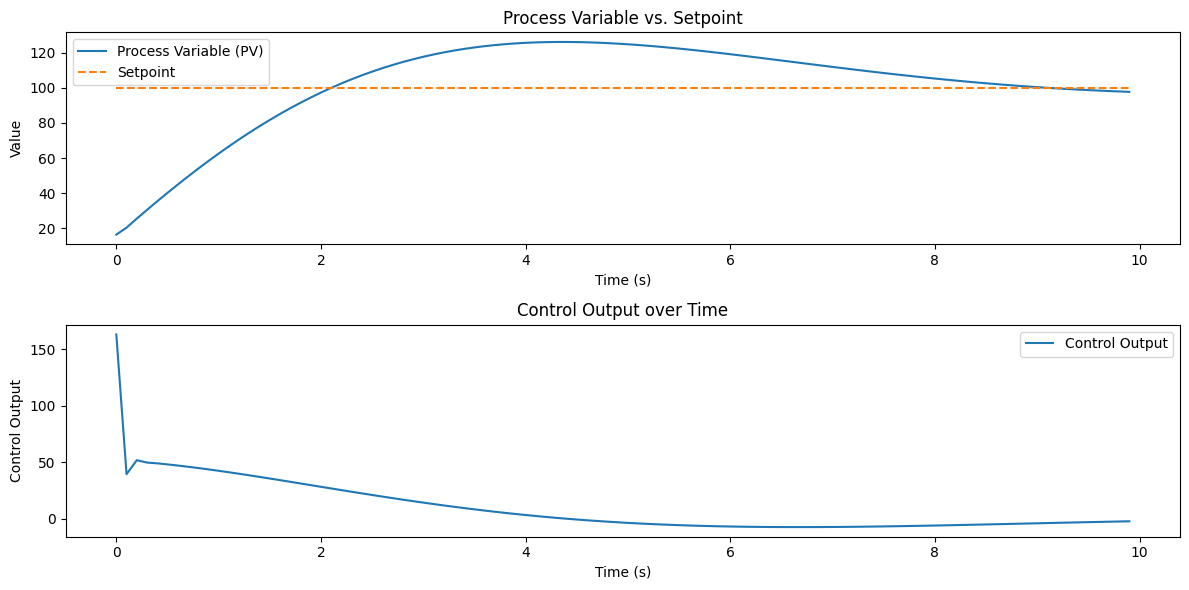

In [5]:
import time
import matplotlib.pyplot as plt

def pid_controller(setpoint, pv, kp, ki, kd, previous_error, integral, dt):
  error = setpoint - pv
  integral += error * dt
  derivative = (error - previous_error) / dt
  control = kp * error + ki * integral + kd * derivative
  return control, error, integral


setpoint = 100
pv = 0
kp = 0.6
ki = 0.3
kf = 0.1
previous_error = 0
integral = 0
dt = 0.1

time_steps = []
pv_values = []
control_values = []
setpoint_values = []

for i in range(100):
  control, error, integral = pid_controller(setpoint, pv, kp, ki, kf, previous_error, integral, dt)
  pv += control * dt
  previous_error = error
  time_steps.append(i*dt)
  pv_values.append(pv)
  control_values.append(control)
  setpoint_values.append(setpoint)
  time.sleep(dt)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time_steps, pv_values, label='Process Variable (PV)')
plt.plot(time_steps, setpoint_values, label='Setpoint', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Process Variable vs. Setpoint')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time_steps, control_values, label='Control Output')
plt.xlabel('Time (s)')
plt.ylabel('Control Output')
plt.title('Control Output over Time')
plt.legend()

plt.tight_layout()
plt.show()
